In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
from pathlib import Path

In [2]:
# === SETTINGS ===
ID = "A2"  # Station ID

# === File Paths ===
dir_path = Path.cwd()  # current working directory
print("Current working directory:", dir_path)

# Data directory 
data_dir = dir_path.parent/ "data"
# Halobates data directory 
halobates_dir =  data_dir / "halobates_data"
# Results directory 
results_dir = dir_path.parent / "results"

# Halobates file
halobates_file = sorted(halobates_dir.glob(f"*{ID}_17_CST_SML.csv"))
halobates_file  = str(halobates_file[0])

# Automatically find the latest (or 'only) file for the given station
SST_files = sorted(results_dir.glob(f"*{ID}_17_IR_SST_clean.csv"))
SST_file = SST_files[0]

# Extract date string from filename
date_str = SST_file.name.split(f"{ID}_17")[0].rstrip("_")

# === Debug output (optional) ===
print("Data directory:", data_dir )
print("Averaged SST clean file:", SST_file)
print("Halobates data file:", halobates_file)
print("\nDate of station:", date_str)

Current working directory: /Users/dimonroy/Library/Mobile Documents/com~apple~CloudDocs/UP_Clouds/SST_RS_Meteor_2025/Infrared_cameras/map_IR
Data directory: /Users/dimonroy/Library/Mobile Documents/com~apple~CloudDocs/UP_Clouds/SST_RS_Meteor_2025/Infrared_cameras/data
Averaged SST clean file: /Users/dimonroy/Library/Mobile Documents/com~apple~CloudDocs/UP_Clouds/SST_RS_Meteor_2025/Infrared_cameras/results/20250626_A2_17_IR_SST_clean.csv
Halobates data file: /Users/dimonroy/Library/Mobile Documents/com~apple~CloudDocs/UP_Clouds/SST_RS_Meteor_2025/Infrared_cameras/data/halobates_data/20250629_A2_17_CST_SML.csv

Date of station: 20250626


In [3]:
# === Load water and sky data ===
df_SST = pd.read_csv(SST_file, sep=",", decimal=".")

# Remove white spaces from the columns titles
df_SST.columns = df_SST.columns.str.strip() 

# Update time format
df_SST['Time'] = pd.to_datetime(df_SST['Time'])

# === Load water and sky data ===
# Load Halobates data
df_halo = pd.read_csv(halobates_file, parse_dates=['Date_Time'])

# Remove white spaces from the columns titles
df_halo.columns =df_halo.columns.str.strip() 

# Rename time column for consistency    
df_halo  = df_halo.rename(columns={'Date_Time': 'Time'})

In [4]:
def filter_overlapping_dates(df1, df2, date_col1='Time', date_col2='Time'):
    """
    Filters two DataFrames to include only rows where the date columns overlap.

    Parameters:
        df1, df2: pandas DataFrames
        date_col1, date_col2: names of the date columns in df1 and df2

    Returns:
        df1_filtered, df2_filtered: DataFrames with only overlapping dates
    """
    # Ensure date columns are datetime type
    df1 = df1.copy()
    df2 = df2.copy()
    df1[date_col1] = pd.to_datetime(df1[date_col1])
    df2[date_col2] = pd.to_datetime(df2[date_col2])

    # Find overlapping dates
    overlapping_dates = set(df1[date_col1]) & set(df2[date_col2])

    # Filter both DataFrames
    df1_filtered = df1[df1[date_col1].isin(overlapping_dates)].sort_values(by=date_col1)
    df2_filtered = df2[df2[date_col2].isin(overlapping_dates)].sort_values(by=date_col2)

    return df1_filtered, df2_filtered

In [5]:
df_halo_overlap, df_SST_overlap = filter_overlapping_dates(df_halo, df_SST)

# === Reset index after filtering ===
df_halo_overlap.reset_index(drop=True, inplace=True)
df_SST_overlap.reset_index(drop=True, inplace=True)

# === Compare lengths ===
len_halo = len(df_halo_overlap)
len_sst = len(df_SST_overlap)

print(f"Halobates rows: {len_halo}, SST rows: {len_sst}")

# === Compare time columns to check alignment ===
if len_halo == len_sst:
    time_diff = df_halo_overlap['Time'] - df_SST_overlap['Time']
    if all(time_diff == pd.Timedelta(0)):
        print("Timestamps are perfectly aligned.")
    else:
        print("Same length but timestamps do not match exactly.")
        print(time_diff.head())
else:
    print("Mismatch in number of data points after filtering.")

Halobates rows: 92342, SST rows: 92342
Timestamps are perfectly aligned.


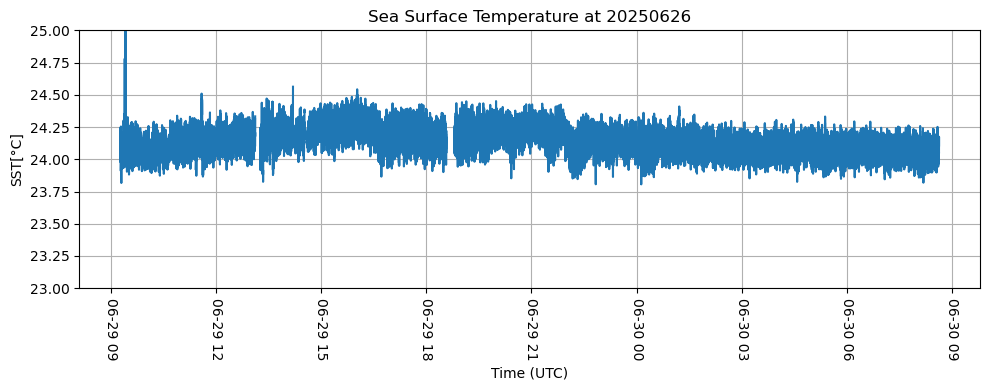

In [6]:
# === Plot ===
plt.figure(figsize=(10, 4))
plt.plot(df_SST_overlap["Time"], df_SST_overlap["SST (°C)"], label="SST")

plt.xlabel("Time (UTC)")
plt.ylabel("SST[°C]")

plt.ylim(23, 25)

plt.xticks(rotation=-90)
plt.title(f"Sea Surface Temperature at {date_str}")
plt.grid(True) 
#plt.legend()
plt.tight_layout()

plt.show()

In [7]:
def map_SST(df_halo_overlap, df_SST_overlap, hour_gap):
    # Sample data
    lats = df_halo_overlap["Latitude"]
    lons = df_halo_overlap["Longitude"]
    temps = df_SST_overlap["SST (°C)"]  # °C
    times = pd.to_datetime(df_halo_overlap["Time"])

    # Set colorbar limits
    temp_min = temps.min()
    temp_max = 24.5

    # Plotting
    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Map features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.LAND, edgecolor='black')

    # Add lat/lon gridlines with labels
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

    # Scatter plot with temperature color scale
    sc = ax.scatter(
        lons, lats, c=temps,
        cmap='coolwarm', s=10,
        vmin=temp_min, vmax=temp_max,
        transform=ccrs.PlateCarree()
    )

    # Add trajectory line
    ax.plot(lons, lats, color='gray', linestyle='--', transform=ccrs.PlateCarree())

    # Label points each hour

    hourly_mask = times.dt.floor('H') != times.shift(1).dt.floor('H')

    lats_hourly = lats[hourly_mask]
    lons_hourly = lons[hourly_mask]
    times_hourly = times[hourly_mask]

    hours_plot = list(range(0, len(lats_hourly), hour_gap))

    lats_filtered = lats_hourly[lats_hourly.index[hours_plot]]
    lons_filtered = lons_hourly[lons_hourly.index[hours_plot]]
    times_filtered= times_hourly[times_hourly.index[hours_plot]]

    for lat, lon, time in zip(lats_filtered , lons_filtered , times_filtered ):
        ax.text(
            lon, lat, time.strftime('%H:%M'),
            fontsize=10, color='black',
            transform=ccrs.PlateCarree()
        )

    # Create colorbar same height as map
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.1, axes_class=plt.Axes)

    cbar = plt.colorbar(sc, cax=cax, orientation='vertical')
    cbar.set_label("SST (°C)")

    # Title centered on map
    ax.set_title("SST Along Trajectory on station " + ID, fontsize=14, loc='center')

    plt.tight_layout()
    plt.show()

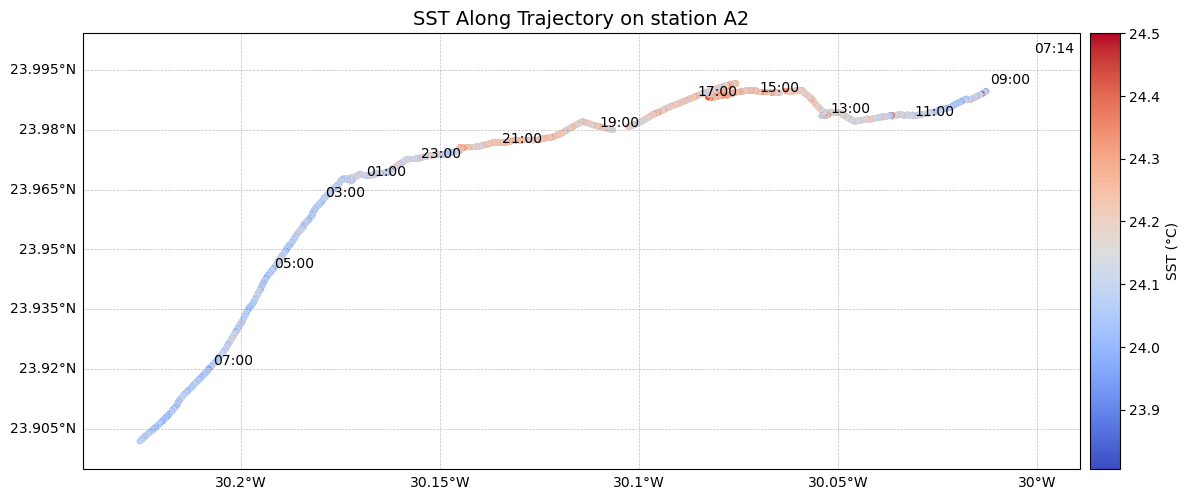

In [ ]:
map_SST(df_halo_overlap, df_SST_overlap, 2)